# Whale Isolation Experiments (DINO seed -> whale pixels)

Start from the local DINOv3 foreground masks that worked in `initial_work_old/dinov3_whale_individuals_experiments.ipynb`, then refine inside that DINO subregion using two image cues:
1. whale pixels tend to be darker than nearby water/glare
2. whale skin is comparatively smooth, so high local texture/edge energy is down-weighted

The final mask grows the refined core a small amount inside the DINO-derived region so edge whale pixels are not accidentally removed.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageOps

try:
    import rawpy
except Exception:
    rawpy = None

try:
    import cv2  # type: ignore
except Exception:
    cv2 = None

try:
    import torch
    import torch.nn.functional as F
    from torchvision import transforms
except Exception:
    torch = None
    F = None
    transforms = None

DINO_REPO_PATH = Path('/home/sat3737/dinov3')
DINO_WEIGHTS_PATH = DINO_REPO_PATH / 'weights' / 'dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth'

if DINO_REPO_PATH.exists() and str(DINO_REPO_PATH) not in sys.path:
    sys.path.insert(0, str(DINO_REPO_PATH))

warnings.filterwarnings('ignore', category=UserWarning)

print('rawpy:', 'ok' if rawpy is not None else 'missing')
print('cv2:', cv2.__version__ if cv2 is not None else 'missing')
print('torch:', torch.__version__ if torch is not None else 'missing')
print('torchvision transforms:', 'ok' if transforms is not None else 'missing')
print('DINO repo:', DINO_REPO_PATH if DINO_REPO_PATH.exists() else 'missing')
print('DINO weights:', DINO_WEIGHTS_PATH if DINO_WEIGHTS_PATH.exists() else 'missing')

rawpy: ok
cv2: 4.13.0
torch: 2.12.1+cu130
torchvision transforms: ok
DINO repo: /home/sat3737/dinov3
DINO weights: /home/sat3737/dinov3/weights/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth


In [ ]:
# If needed, uncomment and run this once in the notebook kernel:
# %pip install -q torch torchvision opencv-python-headless rawpy pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
IMAGE_ROOT = Path('/home/sat3737/Test/Lightroom images/Topside research/2025 Research/2025-1-15')
RANDOM_SEED = 17
SAMPLE_SIZE = 10

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp', '.webp', '.cr2', '.cr3', '.nef', '.arw'}

all_images = [p for p in IMAGE_ROOT.rglob('*') if p.suffix.lower() in IMAGE_EXTS]
if len(all_images) < SAMPLE_SIZE:
    raise ValueError(f'Found only {len(all_images)} images in {IMAGE_ROOT}, need {SAMPLE_SIZE}.')

rng = random.Random(RANDOM_SEED)
sample_paths = sorted(rng.sample(all_images, SAMPLE_SIZE))

print(f'Sampled {len(sample_paths)} images from: {IMAGE_ROOT}')
for i, p in enumerate(sample_paths, start=1):
    print(f'{i:02d}. {p.name}')

Sampled 10 images from: /home/sat3737/Test/Lightroom images/Topside research/2025 Research/2025-1-15
01. 2025-1-15-Lyman-NOAA-MMHSRP-24359-038-HR5_3205.CR3
02. 2025-1-15-Lyman-NOAA-MMHSRP-24359-058-HR5_3225.CR3
03. 2025-1-15-Lyman-NOAA-MMHSRP-24359-070-HR5_3237.CR3
04. 2025-1-15-Lyman-NOAA-MMHSRP-24359-081-HR5_3248.CR3
05. 2025-1-15-Lyman-NOAA-MMHSRP-24359-105-HR5_3272.CR3
06. 2025-1-15-Lyman-NOAA-MMHSRP-24359-155-HR5_3322.CR3
07. 2025-1-15-Lyman-NOAA-MMHSRP-24359-184-HR5_3351.CR3
08. 2025-1-15-Lyman-NOAA-MMHSRP-24359-185-HR5_3352.CR3
09. 2025-1-15-Lyman-NOAA-MMHSRP-24359-205-HR5_3372.CR3
10. 2025-1-15-Lyman-NOAA-MMHSRP-24359-212-HR5_3379.CR3


In [3]:
@dataclass
class MethodResult:
    name: str
    mask: np.ndarray  # bool, HxW
    score_map: np.ndarray | None = None
    note: str = ''


@dataclass
class WhaleMaskResult:
    image: Image.Image
    rgb: np.ndarray
    dino_score: np.ndarray
    dino_mask: np.ndarray
    whale_score: np.ndarray
    whale_core: np.ndarray
    whale_grown: np.ndarray
    note: str


RAW_EXTS = {'.cr2', '.cr3', '.nef', '.arw', '.dng'}


def _to_rgb(path: Path) -> Image.Image:
    path = Path(path)
    if path.suffix.lower() in RAW_EXTS:
        if rawpy is None:
            raise RuntimeError(f'{path.name} is RAW but rawpy is not installed.')
        with rawpy.imread(str(path)) as raw:
            rgb = raw.postprocess(
                use_camera_wb=True,
                no_auto_bright=True,
                output_bps=8,
            )
        return Image.fromarray(rgb, mode='RGB')
    return ImageOps.exif_transpose(Image.open(path)).convert('RGB')


def _normalize01(values: np.ndarray) -> np.ndarray:
    values = values.astype(np.float32)
    finite = np.isfinite(values)
    if not finite.any():
        return np.zeros_like(values, dtype=np.float32)
    lo = float(values[finite].min())
    hi = float(values[finite].max())
    if hi <= lo:
        return np.zeros_like(values, dtype=np.float32)
    out = (values - lo) / (hi - lo + 1e-8)
    out[~finite] = 0.0
    return out.astype(np.float32)


def _resize_float(score: np.ndarray, size: tuple[int, int], resample=Image.Resampling.BILINEAR) -> np.ndarray:
    score_u8 = np.clip(_normalize01(score) * 255.0, 0, 255).astype(np.uint8)
    return np.asarray(Image.fromarray(score_u8, mode='L').resize(size, resample), dtype=np.float32) / 255.0


def _resize_mask(mask: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    mask_u8 = (mask.astype(np.uint8) * 255)
    return np.asarray(Image.fromarray(mask_u8, mode='L').resize(size, Image.Resampling.NEAREST)) > 127


def _disk(radius: int) -> np.ndarray:
    radius = max(1, int(radius))
    if cv2 is not None:
        return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * radius + 1, 2 * radius + 1))
    yy, xx = np.ogrid[-radius:radius + 1, -radius:radius + 1]
    return ((xx * xx + yy * yy) <= radius * radius).astype(bool)


def _binary_dilate(mask: np.ndarray, radius: int = 2, iterations: int = 1) -> np.ndarray:
    mask = mask.astype(bool)
    if radius <= 0 or iterations <= 0:
        return mask
    if cv2 is not None:
        out = cv2.dilate(mask.astype(np.uint8), _disk(radius), iterations=iterations)
        return out > 0
    from scipy import ndimage
    return ndimage.binary_dilation(mask, structure=_disk(radius), iterations=iterations)


def _binary_erode(mask: np.ndarray, radius: int = 1, iterations: int = 1) -> np.ndarray:
    mask = mask.astype(bool)
    if radius <= 0 or iterations <= 0:
        return mask
    if cv2 is not None:
        out = cv2.erode(mask.astype(np.uint8), _disk(radius), iterations=iterations)
        return out > 0
    from scipy import ndimage
    return ndimage.binary_erosion(mask, structure=_disk(radius), iterations=iterations)


def _binary_close(mask: np.ndarray, radius: int = 2) -> np.ndarray:
    if radius <= 0:
        return mask.astype(bool)
    if cv2 is not None:
        out = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, _disk(radius))
        return out > 0
    return _binary_erode(_binary_dilate(mask, radius=radius), radius=radius)


def _fill_holes(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if cv2 is not None:
        h, w = mask.shape
        padded = np.pad(mask.astype(np.uint8), 1, constant_values=0)
        flood = padded.copy()
        cv2.floodFill(flood, None, (0, 0), 1)
        holes = flood[1:h + 1, 1:w + 1] == 0
        return mask | holes
    from scipy import ndimage
    return ndimage.binary_fill_holes(mask)


def _component_stats(mask: np.ndarray):
    mask_u8 = mask.astype(np.uint8)
    if cv2 is not None:
        return cv2.connectedComponentsWithStats(mask_u8, connectivity=8)

    from scipy import ndimage
    labels, count = ndimage.label(mask_u8)
    stats = np.zeros((count + 1, 5), dtype=np.int32)
    for label in range(1, count + 1):
        ys, xs = np.where(labels == label)
        if xs.size == 0:
            continue
        x0, x1 = int(xs.min()), int(xs.max()) + 1
        y0, y1 = int(ys.min()), int(ys.max()) + 1
        stats[label] = (x0, y0, x1 - x0, y1 - y0, xs.size)
    return count + 1, labels, stats, None


def _keep_components(mask: np.ndarray, score: np.ndarray | None = None, min_area: int = 64, keep_count: int = 2) -> np.ndarray:
    n_labels, labels, stats, _ = _component_stats(mask)
    if n_labels <= 1:
        return mask.astype(bool)

    h, w = mask.shape
    ranked = []
    for label in range(1, n_labels):
        x, y, ww, hh, area = stats[label]
        if area < min_area:
            continue
        comp = labels == label
        touches_border = x == 0 or y == 0 or (x + ww) >= w or (y + hh) >= h
        mean_score = float(score[comp].mean()) if score is not None and np.any(comp) else 1.0
        border_penalty = 0.35 if touches_border else 1.0
        ranked.append((area * (0.25 + mean_score) * border_penalty, label))

    if not ranked:
        return mask.astype(bool)

    ranked.sort(reverse=True)
    keep_labels = [label for _, label in ranked[:keep_count]]
    return np.isin(labels, keep_labels)


def _select_quantile_mask(score: np.ndarray, allowed: np.ndarray, min_cov: float, max_cov: float, q_low: float, q_high: float) -> np.ndarray:
    allowed = allowed.astype(bool)
    if not allowed.any():
        return np.zeros_like(allowed, dtype=bool)

    values = score[allowed]
    best = None
    best_dist = float('inf')
    target = 0.5 * (min_cov + max_cov)

    for q in np.linspace(q_high, q_low, 33):
        threshold = float(np.quantile(values, q))
        candidate = allowed & (score >= threshold)
        coverage_inside = float(candidate.sum() / max(allowed.sum(), 1))
        if min_cov <= coverage_inside <= max_cov:
            return candidate
        dist = abs(coverage_inside - target)
        if dist < best_dist:
            best = candidate
            best_dist = dist

    return np.zeros_like(allowed, dtype=bool) if best is None else best


def _local_mean(values: np.ndarray, radius: int) -> np.ndarray:
    k = 2 * radius + 1
    if cv2 is not None:
        return cv2.blur(values.astype(np.float32), (k, k))
    from scipy import ndimage
    return ndimage.uniform_filter(values.astype(np.float32), size=k)


def _local_std(values: np.ndarray, radius: int) -> np.ndarray:
    mean = _local_mean(values, radius)
    mean_sq = _local_mean(values * values, radius)
    return np.sqrt(np.maximum(mean_sq - mean * mean, 0.0)).astype(np.float32)


def _gradient_energy(gray: np.ndarray) -> np.ndarray:
    gray = gray.astype(np.float32)
    if cv2 is not None:
        gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
        return np.sqrt(gx * gx + gy * gy)
    gy, gx = np.gradient(gray)
    return np.sqrt(gx * gx + gy * gy).astype(np.float32)


_dino_model = None
_dino_transform = None
_dino_device = None


def _load_dino_model():
    global _dino_model, _dino_transform, _dino_device
    if torch is None or F is None or transforms is None:
        raise RuntimeError('DINO masks require torch and torchvision.')
    if not DINO_REPO_PATH.exists():
        raise RuntimeError(f'DINO repo not found at {DINO_REPO_PATH}')
    if not DINO_WEIGHTS_PATH.exists():
        raise RuntimeError(f'DINO weights not found at {DINO_WEIGHTS_PATH}')

    _dino_device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if _dino_model is None:
        from dinov3.hub.backbones import dinov3_vitb16
        _dino_model = dinov3_vitb16(pretrained=True, weights=str(DINO_WEIGHTS_PATH)).to(_dino_device).eval()

    if _dino_transform is None:
        _dino_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])

    return _dino_model, _dino_transform, _dino_device


@torch.inference_mode() if torch is not None else (lambda fn: fn)
def _dino_patch_score(image: Image.Image) -> tuple[np.ndarray, np.ndarray]:
    model, dino_transform, device = _load_dino_model()
    model_input = dino_transform(image).unsqueeze(0).to(device)
    features = model.forward_features(model_input)

    patches = features['x_norm_patchtokens'][0].float()
    cls = features['x_norm_clstoken'][0:1].float()
    patch_count = patches.shape[0]
    grid_h = grid_w = int(round(patch_count ** 0.5))
    if grid_h * grid_w != patch_count:
        raise RuntimeError(f'Cannot reshape {patch_count} patch tokens into a square grid.')

    sims = (F.normalize(patches, dim=1) @ F.normalize(cls, dim=1).T).squeeze(1)
    score = sims.detach().cpu().view(grid_h, grid_w).numpy().astype(np.float32)
    score = _normalize01(score)

    if cv2 is not None:
        score = cv2.blur(score, (3, 3))
        score = _normalize01(score)

    return score, score.copy()


def _dino_seed_mask(image: Image.Image) -> tuple[np.ndarray, np.ndarray]:
    w0, h0 = image.size
    small_score, _ = _dino_patch_score(image)
    small_allowed = np.ones_like(small_score, dtype=bool)
    small_mask = _select_quantile_mask(
        small_score,
        small_allowed,
        min_cov=0.08,
        max_cov=0.75,
        q_low=0.42,
        q_high=0.90,
    )
    small_mask = _binary_close(small_mask, radius=1)
    small_mask = _fill_holes(small_mask)
    small_mask = _keep_components(small_mask, small_score, min_area=2, keep_count=2)

    dino_score = _resize_float(small_score, (w0, h0), Image.Resampling.BILINEAR)
    dino_mask = _resize_mask(small_mask, (w0, h0))
    dino_mask = _binary_close(dino_mask, radius=max(2, min(w0, h0) // 220))
    dino_mask = _fill_holes(dino_mask)
    dino_mask = _keep_components(dino_mask, dino_score, min_area=max(128, (w0 * h0) // 1200), keep_count=2)
    return dino_mask, dino_score


def _rgb_to_luma(rgb: np.ndarray) -> np.ndarray:
    rgb01 = rgb.astype(np.float32) / 255.0
    return 0.2126 * rgb01[:, :, 0] + 0.7152 * rgb01[:, :, 1] + 0.0722 * rgb01[:, :, 2]


def _whale_pixel_score(rgb: np.ndarray, dino_mask: np.ndarray, dino_score: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    h, w = dino_mask.shape
    gray = _rgb_to_luma(rgb)

    inner = _binary_erode(dino_mask, radius=max(2, min(h, w) // 250))
    if inner.sum() < max(64, 0.02 * dino_mask.sum()):
        inner = dino_mask.copy()

    context = _binary_dilate(dino_mask, radius=max(8, min(h, w) // 60))
    context_ring = context & ~_binary_erode(dino_mask, radius=max(1, min(h, w) // 300))

    dino_values = gray[dino_mask]
    context_values = gray[context_ring] if context_ring.any() else gray[~dino_mask]
    if context_values.size == 0:
        context_values = gray.reshape(-1)

    whale_dark_ref = float(np.quantile(dino_values, 0.40)) if dino_values.size else float(np.quantile(gray, 0.40))
    bg_bright_ref = float(np.quantile(context_values, 0.58))
    denom = max(bg_bright_ref - whale_dark_ref, 0.05)
    dark_score = np.clip((bg_bright_ref - gray) / denom, 0.0, 1.0)

    color = rgb.astype(np.float32) / 255.0
    chroma_std = np.std(color, axis=2)
    texture = 0.65 * _normalize01(_local_std(gray, radius=max(2, min(h, w) // 180)))
    texture += 0.35 * _normalize01(_gradient_energy(gray))
    smooth_score = 1.0 - _normalize01(texture + 0.30 * chroma_std)

    whale_score = _normalize01(0.48 * dark_score + 0.34 * smooth_score + 0.18 * dino_score)
    whale_score = np.where(dino_mask, whale_score, 0.0).astype(np.float32)
    return whale_score, inner


def refine_whale_mask(path: Path, grow_radius_frac: float = 0.010, max_grow_radius: int = 18) -> WhaleMaskResult:
    image = _to_rgb(path)
    rgb = np.asarray(image)
    h, w = rgb.shape[:2]

    dino_mask, dino_score = _dino_seed_mask(image)
    whale_score, inner = _whale_pixel_score(rgb, dino_mask, dino_score)

    core = _select_quantile_mask(
        whale_score,
        inner,
        min_cov=0.38,
        max_cov=0.88,
        q_low=0.12,
        q_high=0.72,
    )
    core = _binary_close(core, radius=max(2, min(h, w) // 220))
    core = _fill_holes(core)
    core = _keep_components(core, whale_score, min_area=max(96, (h * w) // 3000), keep_count=2)
    core &= dino_mask

    grow_radius = min(max_grow_radius, max(2, int(round(min(h, w) * grow_radius_frac))))
    soft_allowed = _binary_dilate(dino_mask, radius=max(grow_radius, min(h, w) // 120))
    grown = _binary_dilate(core, radius=grow_radius, iterations=1)
    grown = _binary_close(grown, radius=max(2, grow_radius // 2))
    grown = _fill_holes(grown)
    grown &= soft_allowed
    grown = _keep_components(grown, whale_score, min_area=max(128, (h * w) // 2500), keep_count=2)

    if grown.sum() < max(64, 0.05 * dino_mask.sum()):
        grown = dino_mask.copy()
        note = 'fallback=dino_seed'
    else:
        note = f'grow_radius={grow_radius}px'

    note = (
        f'{note}, dino_cov={dino_mask.mean():.3f}, '
        f'core_cov={core.mean():.3f}, grown_cov={grown.mean():.3f}'
    )

    return WhaleMaskResult(
        image=image,
        rgb=rgb,
        dino_score=dino_score,
        dino_mask=dino_mask,
        whale_score=whale_score,
        whale_core=core,
        whale_grown=grown,
        note=note,
    )


def method_dino_seed(path: Path) -> MethodResult:
    result = refine_whale_mask(path)
    return MethodResult(name='dino_seed', mask=result.dino_mask, score_map=result.dino_score, note=result.note)


def methods_from_refined_result(result: WhaleMaskResult) -> list[MethodResult]:
    return [
        MethodResult(name='dino_seed', mask=result.dino_mask, score_map=result.dino_score, note=f'coverage={result.dino_mask.mean():.3f}'),
        MethodResult(name='whale_pixel_core', mask=result.whale_core, score_map=result.whale_score, note=f'coverage={result.whale_core.mean():.3f}'),
        MethodResult(name='whale_pixel_grown', mask=result.whale_grown, score_map=result.whale_score, note=result.note),
    ]


def overlay_mask(rgb: np.ndarray, mask: np.ndarray, color=(255, 90, 20), alpha=0.45) -> np.ndarray:
    out = rgb.copy().astype(np.float32)
    if mask.shape[:2] != out.shape[:2]:
        return out.astype(np.uint8)
    color_arr = np.asarray(color, dtype=np.float32)[None, None, :]
    mask_arr = mask.astype(bool)[:, :, None]
    out = np.where(mask_arr, (1 - alpha) * out + alpha * color_arr, out)
    return np.clip(out, 0, 255).astype(np.uint8)

In [9]:
# Conservative edge-aware overrides.
# Run this after the base helpers above. It intentionally favors recall: a little
# extra water is better than cutting through the whale body during isolation.


def _keep_components_touching(
    mask: np.ndarray,
    support: np.ndarray,
    min_area: int = 64,
    keep_count: int | None = None,
) -> np.ndarray:
    n_labels, labels, stats, _ = _component_stats(mask)
    if n_labels <= 1:
        return mask.astype(bool)

    ranked = []
    for label in range(1, n_labels):
        area = int(stats[label, 4])
        if area < min_area:
            continue
        comp = labels == label
        overlap = int((comp & support).sum())
        if overlap <= 0:
            continue
        ranked.append((overlap, area, label))

    if not ranked:
        return mask.astype(bool)

    ranked.sort(reverse=True)
    labels_to_keep = [label for _, _, label in ranked]
    if keep_count is not None:
        labels_to_keep = labels_to_keep[:keep_count]
    return np.isin(labels, labels_to_keep)


def _dino_seed_mask(image: Image.Image) -> tuple[np.ndarray, np.ndarray]:
    w0, h0 = image.size
    small_score, _ = _dino_patch_score(image)

    high_threshold = float(np.quantile(small_score, 0.86))
    wide_threshold = float(np.quantile(small_score, 0.66))
    high_conf = small_score >= high_threshold
    wide_candidate = small_score >= wide_threshold

    high_support = _binary_dilate(high_conf, radius=1)
    small_mask = _keep_components_touching(wide_candidate, high_support, min_area=1, keep_count=3)
    small_mask = _binary_close(small_mask, radius=1)
    small_mask = _fill_holes(small_mask)
    small_mask = _keep_components(small_mask, small_score, min_area=2, keep_count=3)

    dino_score = _resize_float(small_score, (w0, h0), Image.Resampling.BILINEAR)
    dino_mask = _resize_mask(small_mask, (w0, h0))
    dino_mask = _binary_dilate(dino_mask, radius=max(3, min(w0, h0) // 180))
    dino_mask = _binary_close(dino_mask, radius=max(3, min(w0, h0) // 180))
    dino_mask = _fill_holes(dino_mask)
    dino_mask = _keep_components(dino_mask, dino_score, min_area=max(128, (w0 * h0) // 1800), keep_count=3)
    return dino_mask, dino_score


def _whale_pixel_score(rgb: np.ndarray, dino_mask: np.ndarray, dino_score: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    h, w = dino_mask.shape
    gray = _rgb_to_luma(rgb)

    context = _binary_dilate(dino_mask, radius=max(12, min(h, w) // 45))
    context_ring = context & ~_binary_erode(dino_mask, radius=max(1, min(h, w) // 320))

    dino_values = gray[dino_mask]
    context_values = gray[context_ring] if context_ring.any() else gray[~dino_mask]
    if context_values.size == 0:
        context_values = gray.reshape(-1)

    whale_dark_ref = float(np.quantile(dino_values, 0.45)) if dino_values.size else float(np.quantile(gray, 0.45))
    bg_bright_ref = float(np.quantile(context_values, 0.62))
    denom = max(bg_bright_ref - whale_dark_ref, 0.05)
    dark_score = np.clip((bg_bright_ref - gray) / denom, 0.0, 1.0)

    color = rgb.astype(np.float32) / 255.0
    chroma_std = np.std(color, axis=2)
    texture_only = _normalize01(_local_std(gray, radius=max(2, min(h, w) // 180)))
    smooth_score = 1.0 - _normalize01(texture_only + 0.25 * chroma_std)

    edge_score = _normalize01(_gradient_energy(gray))
    profile_edge_hint = _normalize01(edge_score * np.maximum(dark_score, dino_score))

    whale_score = _normalize01(
        0.43 * dark_score
        + 0.24 * smooth_score
        + 0.21 * dino_score
        + 0.12 * profile_edge_hint
    )
    whale_score = np.where(dino_mask, whale_score, 0.0).astype(np.float32)
    return whale_score, dino_mask.copy()


def _profile_edge_support(
    rgb: np.ndarray,
    dino_mask: np.ndarray,
    core: np.ndarray,
    whale_score: np.ndarray,
) -> np.ndarray:
    h, w = dino_mask.shape
    gray = _rgb_to_luma(rgb)
    gray_u8 = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    allowed = _binary_dilate(dino_mask, radius=max(4, min(h, w) // 170))

    gradient = _normalize01(_gradient_energy(gray))
    grad_values = gradient[allowed]
    if grad_values.size == 0:
        return np.zeros_like(dino_mask, dtype=bool)

    if cv2 is not None:
        blurred = cv2.GaussianBlur(gray_u8, (5, 5), 0)
        high = max(24, int(round(255.0 * float(np.quantile(grad_values, 0.84)))))
        low = max(8, int(round(0.45 * high)))
        edges = cv2.Canny(blurred, low, high) > 0
    else:
        edges = gradient >= float(np.quantile(grad_values, 0.86))

    edges &= allowed
    edges = _binary_close(edges, radius=max(1, min(h, w) // 700))
    edge_band = _binary_dilate(edges, radius=max(3, min(h, w) // 260))

    score_values = whale_score[dino_mask]
    if score_values.size:
        low_body = dino_mask & (whale_score >= float(np.quantile(score_values, 0.30)))
    else:
        low_body = dino_mask.copy()

    support = _binary_dilate(core | low_body, radius=max(16, min(h, w) // 55))
    edge_band = _keep_components_touching(
        edge_band,
        support,
        min_area=max(48, (h * w) // 20000),
        keep_count=8,
    )

    profile = _binary_close(edge_band | core | low_body, radius=max(4, min(h, w) // 220))
    profile = _fill_holes(profile)
    profile &= allowed
    profile = _keep_components_touching(
        profile,
        support,
        min_area=max(128, (h * w) // 5000),
        keep_count=3,
    )
    return profile


def refine_whale_mask(path: Path, grow_radius_frac: float = 0.018, max_grow_radius: int = 32) -> WhaleMaskResult:
    image = _to_rgb(path)
    rgb = np.asarray(image)
    h, w = rgb.shape[:2]

    dino_mask, dino_score = _dino_seed_mask(image)
    whale_score, allowed = _whale_pixel_score(rgb, dino_mask, dino_score)

    core = _select_quantile_mask(
        whale_score,
        allowed,
        min_cov=0.42,
        max_cov=0.92,
        q_low=0.08,
        q_high=0.66,
    )
    core = _binary_close(core, radius=max(2, min(h, w) // 220))
    core = _fill_holes(core)
    core = _keep_components(core, whale_score, min_area=max(96, (h * w) // 3500), keep_count=3)
    core &= dino_mask

    profile = _profile_edge_support(rgb, dino_mask, core, whale_score)

    score_values = whale_score[dino_mask]
    if score_values.size:
        body_floor = float(np.quantile(score_values, 0.24))
        low_conf_body = dino_mask & (whale_score >= body_floor)
    else:
        body_floor = 0.0
        low_conf_body = dino_mask.copy()
    low_conf_body = _keep_components_touching(
        low_conf_body,
        _binary_dilate(core | profile, radius=max(16, min(h, w) // 60)),
        min_area=max(128, (h * w) // 4500),
        keep_count=3,
    )

    grow_radius = min(max_grow_radius, max(4, int(round(min(h, w) * grow_radius_frac))))
    soft_allowed = _binary_dilate(dino_mask, radius=max(grow_radius, min(h, w) // 95))
    grown = core | profile | low_conf_body
    grown = _binary_dilate(grown, radius=grow_radius, iterations=1)
    grown = _binary_close(grown, radius=max(3, grow_radius // 2))
    grown = _fill_holes(grown)
    grown &= soft_allowed
    grown = _keep_components_touching(
        grown,
        _binary_dilate(core | profile, radius=max(20, min(h, w) // 50)),
        min_area=max(128, (h * w) // 3500),
        keep_count=3,
    )

    min_final_pixels = int(round(0.72 * dino_mask.sum()))
    if grown.sum() < min_final_pixels:
        conservative_keep = _keep_components_touching(
            dino_mask,
            _binary_dilate(core | profile, radius=max(24, min(h, w) // 45)),
            min_area=max(128, (h * w) // 3500),
            keep_count=3,
        )
        grown |= conservative_keep
        grown &= soft_allowed
        note_prefix = 'conservative_dino_union'
    else:
        note_prefix = 'edge_profile_rescue'

    note = (
        f'{note_prefix}, grow_radius={grow_radius}px, body_floor={body_floor:.3f}, '
        f'dino_cov={dino_mask.mean():.3f}, core_cov={core.mean():.3f}, '
        f'profile_cov={profile.mean():.3f}, grown_cov={grown.mean():.3f}'
    )

    return WhaleMaskResult(
        image=image,
        rgb=rgb,
        dino_score=dino_score,
        dino_mask=dino_mask,
        whale_score=whale_score,
        whale_core=core,
        whale_grown=grown,
        note=note,
    )

In [11]:
# Fast conservative refinement wrapper.
# The DINO signal is patch-level and the profile rescue is shape-level, so doing
# the heavy morphology on a bounded analysis image is much faster while still
# returning full-resolution masks for inspection/export.


def _analysis_image(image: Image.Image, max_side: int = 2200) -> tuple[Image.Image, float]:
    w, h = image.size
    scale = min(1.0, float(max_side) / float(max(w, h)))
    if scale >= 1.0:
        return image, 1.0
    size = (max(1, int(round(w * scale))), max(1, int(round(h * scale))))
    return image.resize(size, Image.Resampling.BILINEAR), scale


def refine_whale_mask(
    path: Path,
    grow_radius_frac: float = 0.018,
    max_grow_radius: int = 32,
    analysis_max_side: int = 2200,
) -> WhaleMaskResult:
    full_image = _to_rgb(path)
    full_w, full_h = full_image.size
    image, scale = _analysis_image(full_image, max_side=analysis_max_side)
    rgb = np.asarray(image)
    h, w = rgb.shape[:2]

    dino_mask, dino_score = _dino_seed_mask(image)
    whale_score, allowed = _whale_pixel_score(rgb, dino_mask, dino_score)

    core = _select_quantile_mask(
        whale_score,
        allowed,
        min_cov=0.42,
        max_cov=0.92,
        q_low=0.08,
        q_high=0.66,
    )
    core = _binary_close(core, radius=max(2, min(h, w) // 220))
    core = _fill_holes(core)
    core = _keep_components(core, whale_score, min_area=max(48, (h * w) // 3500), keep_count=3)
    core &= dino_mask

    profile = _profile_edge_support(rgb, dino_mask, core, whale_score)

    score_values = whale_score[dino_mask]
    if score_values.size:
        body_floor = float(np.quantile(score_values, 0.24))
        low_conf_body = dino_mask & (whale_score >= body_floor)
    else:
        body_floor = 0.0
        low_conf_body = dino_mask.copy()
    low_conf_body = _keep_components_touching(
        low_conf_body,
        _binary_dilate(core | profile, radius=max(8, min(h, w) // 60)),
        min_area=max(48, (h * w) // 4500),
        keep_count=3,
    )

    full_grow_radius = min(max_grow_radius, max(4, int(round(min(full_h, full_w) * grow_radius_frac))))
    grow_radius = max(2, int(round(full_grow_radius * scale)))
    soft_allowed = _binary_dilate(dino_mask, radius=max(grow_radius, min(h, w) // 95))
    grown = core | profile | low_conf_body
    grown = _binary_dilate(grown, radius=grow_radius, iterations=1)
    grown = _binary_close(grown, radius=max(2, grow_radius // 2))
    grown = _fill_holes(grown)
    grown &= soft_allowed
    grown = _keep_components_touching(
        grown,
        _binary_dilate(core | profile, radius=max(10, min(h, w) // 50)),
        min_area=max(48, (h * w) // 3500),
        keep_count=3,
    )

    min_final_pixels = int(round(0.72 * dino_mask.sum()))
    if grown.sum() < min_final_pixels:
        conservative_keep = _keep_components_touching(
            dino_mask,
            _binary_dilate(core | profile, radius=max(12, min(h, w) // 45)),
            min_area=max(48, (h * w) // 3500),
            keep_count=3,
        )
        grown |= conservative_keep
        grown &= soft_allowed
        note_prefix = 'conservative_dino_union'
    else:
        note_prefix = 'edge_profile_rescue'

    dino_mask_full = _resize_mask(dino_mask, (full_w, full_h))
    core_full = _resize_mask(core, (full_w, full_h))
    grown_full = _resize_mask(grown, (full_w, full_h))
    dino_score_full = _resize_float(dino_score, (full_w, full_h), Image.Resampling.BILINEAR)
    whale_score_full = _resize_float(whale_score, (full_w, full_h), Image.Resampling.BILINEAR)

    note = (
        f'{note_prefix}, analysis_scale={scale:.3f}, grow_radius={full_grow_radius}px, '
        f'body_floor={body_floor:.3f}, dino_cov={dino_mask_full.mean():.3f}, '
        f'core_cov={core_full.mean():.3f}, profile_cov={_resize_mask(profile, (full_w, full_h)).mean():.3f}, '
        f'grown_cov={grown_full.mean():.3f}'
    )

    return WhaleMaskResult(
        image=full_image,
        rgb=np.asarray(full_image),
        dino_score=dino_score_full,
        dino_mask=dino_mask_full,
        whale_score=whale_score_full,
        whale_core=core_full,
        whale_grown=grown_full,
        note=note,
    )

In [ ]:
# Shape-constrained conservative final mask.
# DINO is the outer safety fence. The final mask must stay connected to body
# evidence, so it can preserve whale edges without filling the whole DINO block.


def _edge_band(rgb: np.ndarray, allowed: np.ndarray, support: np.ndarray) -> np.ndarray:
    h, w = allowed.shape
    if not allowed.any() or not support.any():
        return np.zeros_like(allowed, dtype=bool)

    gray = _rgb_to_luma(rgb)
    gray_u8 = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    gradient = _normalize01(_gradient_energy(gray))

    near_support = _binary_dilate(support, radius=max(8, min(h, w) // 70)) & allowed
    values = gradient[near_support] if near_support.any() else gradient[allowed]
    if values.size == 0:
        return np.zeros_like(allowed, dtype=bool)

    if cv2 is not None:
        blurred = cv2.GaussianBlur(gray_u8, (5, 5), 0)
        high = max(28, int(round(255.0 * float(np.quantile(values, 0.91)))))
        low = max(10, int(round(0.45 * high)))
        edges = cv2.Canny(blurred, low, high) > 0
    else:
        edges = gradient >= float(np.quantile(values, 0.92))

    edges &= near_support
    band = _binary_dilate(edges, radius=max(1, min(h, w) // 500))
    band = _keep_components_touching(
        band,
        _binary_dilate(support, radius=max(4, min(h, w) // 160)),
        min_area=max(12, (h * w) // 60000),
        keep_count=10,
    )
    return band & allowed


def _grabcut_body_mask(
    rgb: np.ndarray,
    allowed: np.ndarray,
    core: np.ndarray,
    whale_score: np.ndarray,
    edge_band: np.ndarray,
) -> np.ndarray:
    h, w = allowed.shape
    if not allowed.any() or not core.any():
        return core & allowed

    support = core | edge_band
    near_support = _binary_dilate(support, radius=max(12, min(h, w) // 55)) & allowed

    if cv2 is None:
        values = whale_score[near_support] if near_support.any() else whale_score[allowed]
        floor = float(np.quantile(values, 0.40)) if values.size else 0.0
        mask = near_support & (whale_score >= floor)
        mask |= support
        return _fill_holes(_binary_close(mask, radius=max(2, min(h, w) // 260))) & allowed

    score_values = whale_score[near_support] if near_support.any() else whale_score[allowed]
    if score_values.size == 0:
        return core & allowed

    probable_floor = float(np.quantile(score_values, 0.48))
    sure_floor = float(np.quantile(score_values, 0.78))

    probable_fg = near_support & (whale_score >= probable_floor)
    probable_fg |= _binary_dilate(support, radius=max(2, min(h, w) // 260)) & allowed
    sure_fg = (near_support & (whale_score >= sure_floor)) | _binary_erode(core, radius=max(1, min(h, w) // 450))
    sure_fg = _keep_components_touching(
        sure_fg,
        support | probable_fg,
        min_area=max(8, (h * w) // 100000),
        keep_count=6,
    )
    if sure_fg.sum() < max(16, 0.003 * allowed.sum()):
        sure_fg = _keep_components_touching(
            core,
            probable_fg | support,
            min_area=max(8, (h * w) // 100000),
            keep_count=6,
        )

    outer_fence = _binary_dilate(allowed, radius=max(2, min(h, w) // 260))
    gc_mask = np.full((h, w), cv2.GC_BGD, dtype=np.uint8)
    gc_mask[outer_fence] = cv2.GC_PR_BGD
    gc_mask[probable_fg] = cv2.GC_PR_FGD
    gc_mask[sure_fg] = cv2.GC_FGD
    gc_mask[~outer_fence] = cv2.GC_BGD

    if not np.any(gc_mask == cv2.GC_FGD) or not np.any(gc_mask == cv2.GC_PR_BGD):
        mask = probable_fg
    else:
        image_bgr = cv2.cvtColor(rgb.astype(np.uint8), cv2.COLOR_RGB2BGR)
        bgd_model = np.zeros((1, 65), np.float64)
        fgd_model = np.zeros((1, 65), np.float64)
        try:
            cv2.grabCut(image_bgr, gc_mask, None, bgd_model, fgd_model, 4, cv2.GC_INIT_WITH_MASK)
            mask = (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD)
        except cv2.error:
            mask = probable_fg

    reach = _binary_dilate(probable_fg | sure_fg | support, radius=max(10, min(h, w) // 65)) & outer_fence
    mask &= reach
    mask |= sure_fg | support
    mask = _binary_close(mask, radius=max(2, min(h, w) // 260))
    mask = _fill_holes(mask)
    mask = _keep_components_touching(
        mask,
        _binary_dilate(support | sure_fg, radius=max(6, min(h, w) // 120)),
        min_area=max(24, (h * w) // 30000),
        keep_count=5,
    )
    return mask & outer_fence


def refine_whale_mask(
    path: Path,
    grow_radius_frac: float = 0.007,
    max_grow_radius: int = 14,
    analysis_max_side: int = 2200,
) -> WhaleMaskResult:
    full_image = _to_rgb(path)
    full_w, full_h = full_image.size
    image, scale = _analysis_image(full_image, max_side=analysis_max_side)
    rgb = np.asarray(image)
    h, w = rgb.shape[:2]

    dino_mask, dino_score = _dino_seed_mask(image)
    whale_score, allowed = _whale_pixel_score(rgb, dino_mask, dino_score)

    core = _select_quantile_mask(
        whale_score,
        allowed,
        min_cov=0.30,
        max_cov=0.76,
        q_low=0.22,
        q_high=0.76,
    )
    core = _binary_close(core, radius=max(2, min(h, w) // 280))
    core = _fill_holes(core)
    core = _keep_components(core, whale_score, min_area=max(24, (h * w) // 9000), keep_count=4)
    core &= allowed

    edges = _edge_band(rgb, allowed, core)
    grabcut_mask = _grabcut_body_mask(rgb, allowed, core, whale_score, edges)

    full_grow_radius = min(max_grow_radius, max(2, int(round(min(full_h, full_w) * grow_radius_frac))))
    grow_radius = max(1, int(round(full_grow_radius * scale)))
    grown = _binary_dilate(grabcut_mask | core | edges, radius=grow_radius, iterations=1)
    grown = _binary_close(grown, radius=max(1, grow_radius // 2))
    grown = _fill_holes(grown)
    outer_fence = _binary_dilate(allowed, radius=max(grow_radius, min(h, w) // 220))
    grown &= outer_fence
    grown = _keep_components_touching(
        grown,
        _binary_dilate(core | edges | grabcut_mask, radius=max(6, min(h, w) // 120)),
        min_area=max(24, (h * w) // 30000),
        keep_count=5,
    )

    min_keep = int(round(max(0.85 * core.sum(), 0.55 * grabcut_mask.sum())))
    if grown.sum() < max(32, min_keep):
        grown = _binary_dilate(core | edges, radius=max(2, grow_radius), iterations=1)
        grown &= outer_fence
        note_prefix = 'edge_core_fallback'
    else:
        note_prefix = 'grabcut_edge_profile'

    dino_mask_full = _resize_mask(dino_mask, (full_w, full_h))
    core_full = _resize_mask(core, (full_w, full_h))
    grown_full = _resize_mask(grown, (full_w, full_h))
    dino_score_full = _resize_float(dino_score, (full_w, full_h), Image.Resampling.BILINEAR)
    whale_score_full = _resize_float(whale_score, (full_w, full_h), Image.Resampling.BILINEAR)

    note = (
        f'{note_prefix}, analysis_scale={scale:.3f}, grow_radius={full_grow_radius}px, '
        f'dino_cov={dino_mask_full.mean():.3f}, core_cov={core_full.mean():.3f}, '
        f'edge_cov={_resize_mask(edges, (full_w, full_h)).mean():.3f}, '
        f'grabcut_cov={_resize_mask(grabcut_mask, (full_w, full_h)).mean():.3f}, '
        f'grown_cov={grown_full.mean():.3f}'
    )

    return WhaleMaskResult(
        image=full_image,
        rgb=np.asarray(full_image),
        dino_score=dino_score_full,
        dino_mask=dino_mask_full,
        whale_score=whale_score_full,
        whale_core=core_full,
        whale_grown=grown_full,
        note=note,
    )

In [4]:
def run_all_methods(path: Path) -> list[MethodResult]:
    result = refine_whale_mask(path)
    return methods_from_refined_result(result)


def run_refined(path: Path) -> dict:
    result = refine_whale_mask(path)
    methods = methods_from_refined_result(result)
    return {'path': path, 'rgb': result.rgb, 'refined': result, 'methods': methods}

In [17]:
# Debug: test the DINO-seeded whale-pixel refinement on the first image.
try:
    test_row = run_refined(sample_paths[0])
    for method in test_row['methods']:
        print(f'{method.name}: mask shape={method.mask.shape}, coverage={float(method.mask.mean()):.4f}, note={method.note}')
except Exception as exc:
    import traceback
    print('DINO-seeded refinement failed:')
    traceback.print_exc()

dino_seed: mask shape=(5463, 8191), coverage=0.3549, note=coverage=0.355
whale_pixel_core: mask shape=(5463, 8191), coverage=0.2277, note=coverage=0.228
whale_pixel_grown: mask shape=(5463, 8191), coverage=0.3601, note=grabcut_edge_profile, analysis_scale=0.269, grow_radius=18px, dino_cov=0.355, core_cov=0.228, edge_cov=0.292, grabcut_cov=0.351, grown_cov=0.360


In [13]:
all_results = []

for path in sample_paths:
    row = run_refined(path)
    for method in row['methods']:
        if method.mask.shape == row['rgb'].shape[:2]:
            row[f'{method.name}_coverage'] = float(method.mask.mean())
        else:
            row[f'{method.name}_coverage'] = np.nan
    all_results.append(row)

print(f'Processed {len(all_results)} sampled images.')

Processed 10 sampled images.


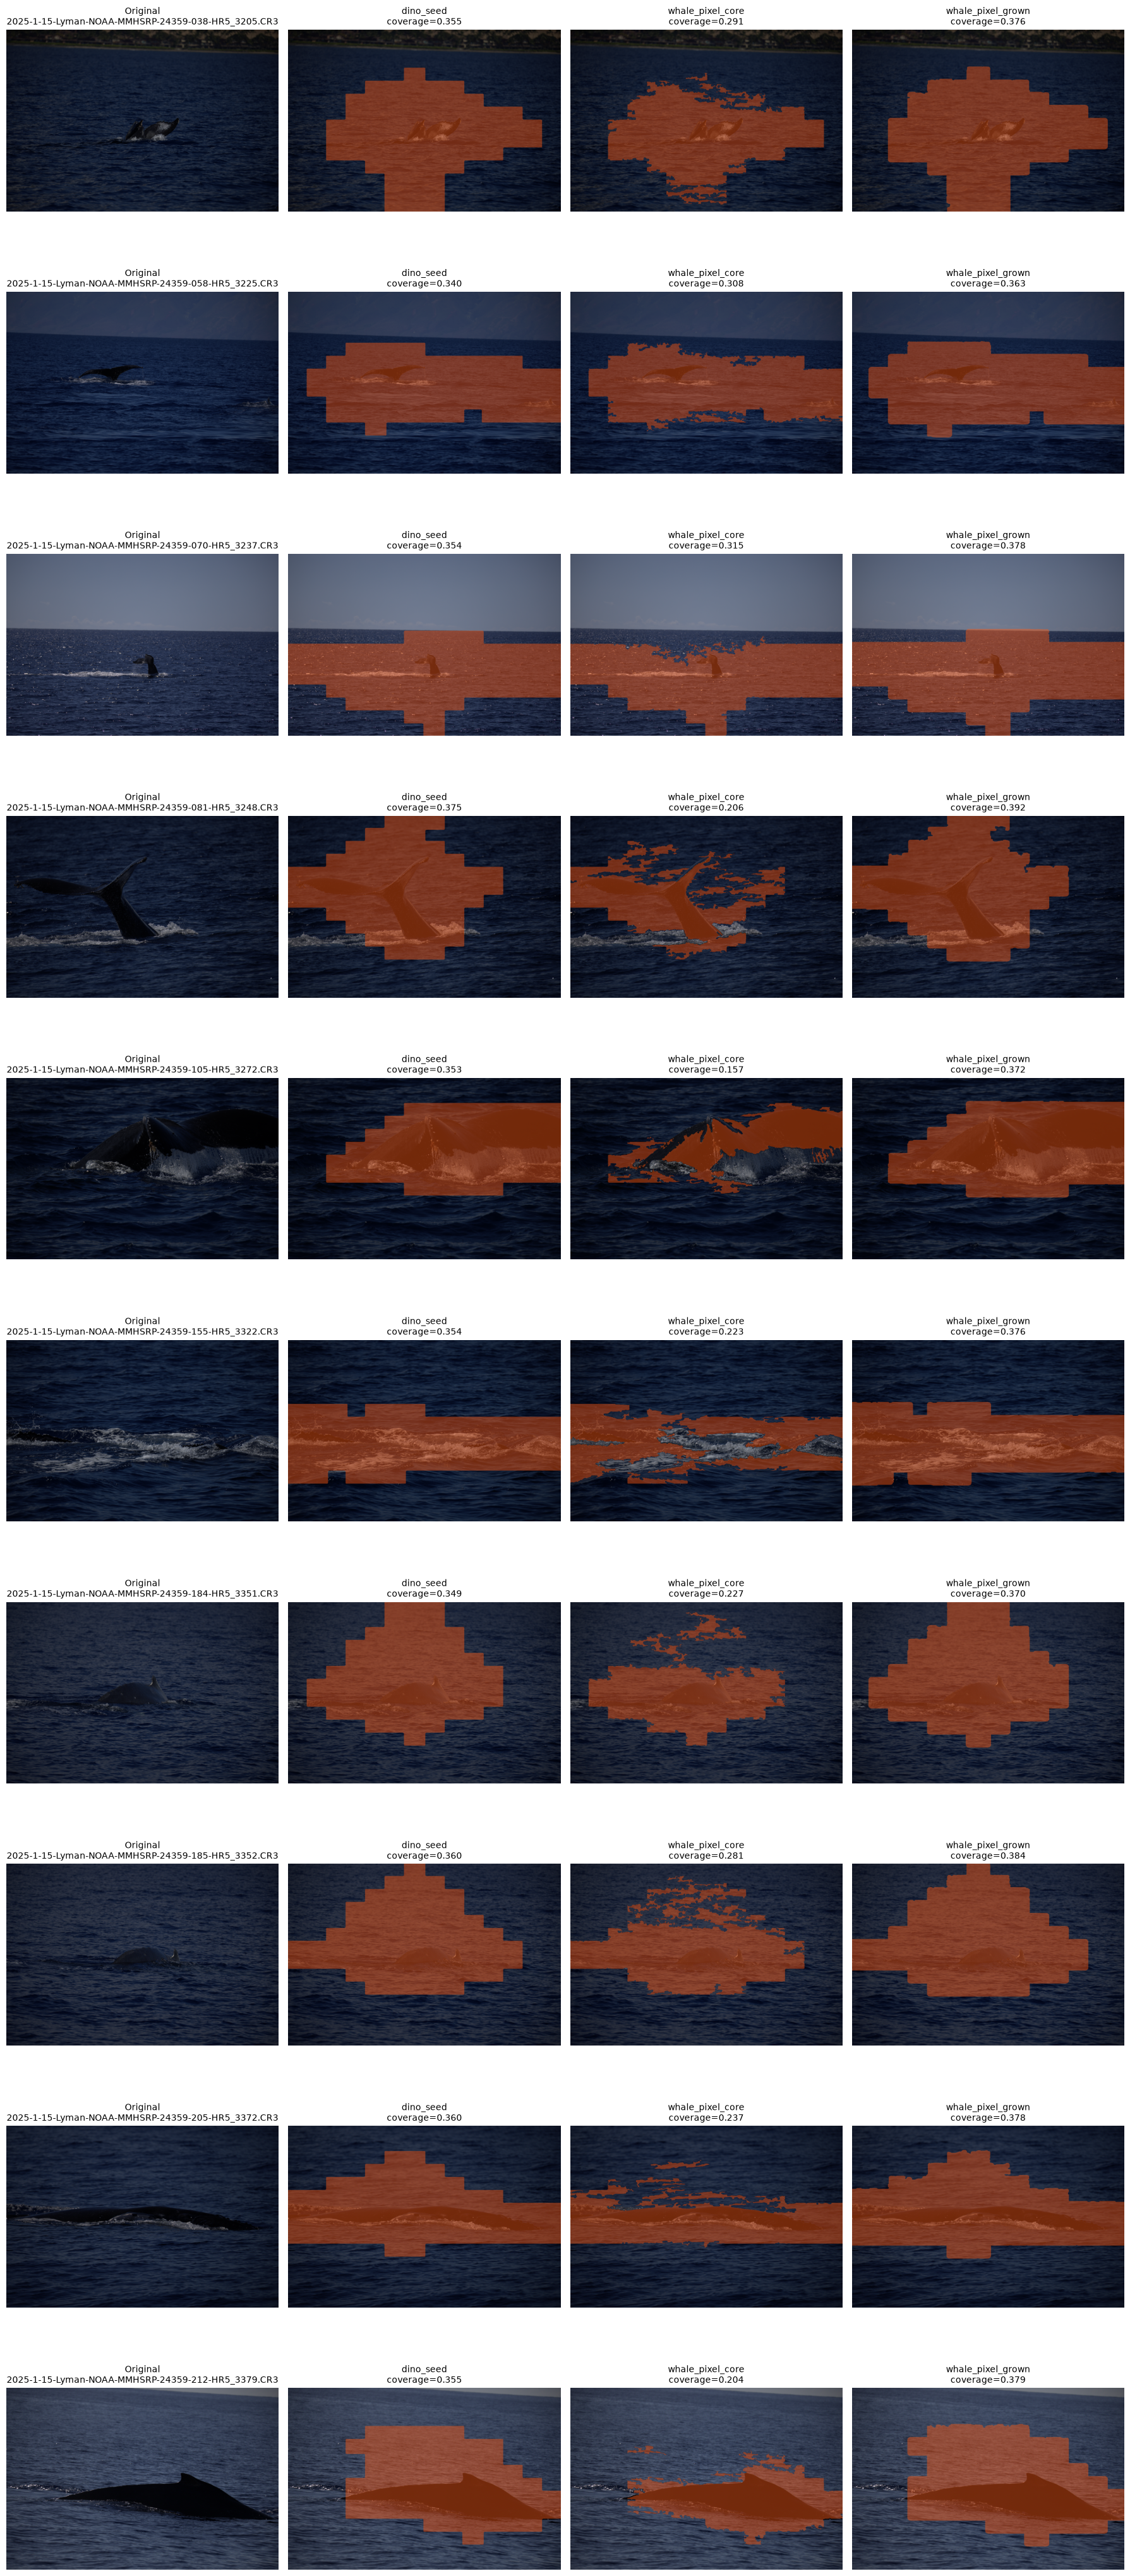

In [15]:
DISPLAY_MAX_SIDE = 1400


def _display_rgb_mask(rgb: np.ndarray, mask: np.ndarray | None = None, max_side: int = DISPLAY_MAX_SIDE):
    h, w = rgb.shape[:2]
    scale = min(1.0, float(max_side) / float(max(h, w)))
    if scale < 1.0:
        size = (max(1, int(round(w * scale))), max(1, int(round(h * scale))))
        rgb_vis = np.asarray(Image.fromarray(rgb).resize(size, Image.Resampling.BILINEAR))
        if mask is None:
            return rgb_vis, None
        mask_vis = _resize_mask(mask, size)
        return rgb_vis, mask_vis
    return rgb, mask


n = len(all_results)
fig, axes = plt.subplots(nrows=n, ncols=4, figsize=(18, 4.2 * n))
if n == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in enumerate(all_results):
    rgb = row['rgb']
    rgb_vis, _ = _display_rgb_mask(rgb)
    axes[i, 0].imshow(rgb_vis)
    axes[i, 0].set_title(f'Original\n{row["path"].name}', fontsize=10)
    axes[i, 0].axis('off')

    for col, method in enumerate(row['methods'], start=1):
        if method.mask.shape == rgb.shape[:2]:
            rgb_method, mask_method = _display_rgb_mask(rgb, method.mask)
            vis = overlay_mask(rgb_method, mask_method)
            coverage = float(method.mask.mean())
            subtitle = f'{method.name}\ncoverage={coverage:.3f}'
        else:
            vis = rgb_vis
            subtitle = f'{method.name}\n{method.note}'
        axes[i, col].imshow(vis)
        axes[i, col].set_title(subtitle, fontsize=10)
        axes[i, col].axis('off')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

summary_rows = []
for row in all_results:
    r = {'image': row['path'].name}
    for m in row['methods']:
        key = f'{m.name}_coverage'
        r[key] = row.get(key, np.nan)
        if m.note:
            r[f'{m.name}_note'] = m.note
    summary_rows.append(r)

df = pd.DataFrame(summary_rows)
display(df)

coverage_cols = [c for c in df.columns if c.endswith('_coverage')]
print('Mean coverage by method:')
display(df[coverage_cols].mean(numeric_only=True).sort_values(ascending=False).to_frame('mean_coverage'))

,image,dino_seed_coverage,dino_seed_note,whale_pixel_core_coverage,whale_pixel_core_note,whale_pixel_grown_coverage,whale_pixel_grown_note
0,2025-1-15-Lyman-NOAA-MMHSRP-24359-038-HR5_3205...,0.354871,coverage=0.355,0.290528,coverage=0.291,0.376478,"edge_profile_rescue, analysis_scale=0.269, gro..."
1,2025-1-15-Lyman-NOAA-MMHSRP-24359-058-HR5_3225...,0.339753,coverage=0.340,0.307933,coverage=0.308,0.363082,"edge_profile_rescue, analysis_scale=0.269, gro..."
2,2025-1-15-Lyman-NOAA-MMHSRP-24359-070-HR5_3237...,0.354261,coverage=0.354,0.315129,coverage=0.315,0.377746,"edge_profile_rescue, analysis_scale=0.269, gro..."
3,2025-1-15-Lyman-NOAA-MMHSRP-24359-081-HR5_3248...,0.375396,coverage=0.375,0.205805,coverage=0.206,0.391724,"edge_profile_rescue, analysis_scale=0.269, gro..."
4,2025-1-15-Lyman-NOAA-MMHSRP-24359-105-HR5_3272...,0.352969,coverage=0.353,0.157456,coverage=0.157,0.372010,"edge_profile_rescue, analysis_scale=0.269, gro..."
5,2025-1-15-Lyman-NOAA-MMHSRP-24359-155-HR5_3322...,0.354137,coverage=0.354,0.222570,coverage=0.223,0.376114,"edge_profile_rescue, analysis_scale=0.269, gro..."
6,2025-1-15-Lyman-NOAA-MMHSRP-24359-184-HR5_3351...,0.348959,coverage=0.349,0.227392,coverage=0.227,0.369646,"edge_profile_rescue, analysis_scale=0.269, gro..."
7,2025-1-15-Lyman-NOAA-MMHSRP-24359-185-HR5_3352...,0.360364,coverage=0.360,0.281023,coverage=0.281,0.383977,"edge_profile_rescue, analysis_scale=0.269, gro..."
8,2025-1-15-Lyman-NOAA-MMHSRP-24359-205-HR5_3372...,0.359937,coverage=0.360,0.236995,coverage=0.237,0.377679,"edge_profile_rescue, analysis_scale=0.269, gro..."
9,2025-1-15-Lyman-NOAA-MMHSRP-24359-212-HR5_3379...,0.355447,coverage=0.355,0.203664,coverage=0.204,0.378530,"edge_profile_rescue, analysis_scale=0.269, gro..."


Mean coverage by method:


,mean_coverage
whale_pixel_grown_coverage,0.376699
dino_seed_coverage,0.355609
whale_pixel_core_coverage,0.244850
